Image Inpainting (Digital Photo Patching)

The Problem: You have a photograph with a scratch, an ink spot, or a scribble on it
. If you just delete those pixels, you will be left with an ugly black or white hole.
The Intuition: Inpainting works by looking at the undamaged pixel textures surrounding the scratch and copying/blending those patterns inward

It fills in the damaged area so seamlessly that the scratch becomes completely invisible to the human eye


The "Secret Map" (The Mask): To do this, the computer needs a mask
. A mask is a simple black-and-white map where black pixels represents the healthy, original image that must be kept, and white pixels indicate the damaged areas that need to be inpainted


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

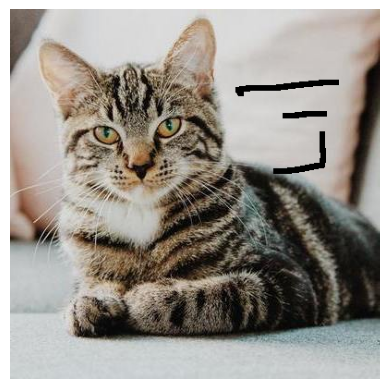

In [6]:
img = cv2.imread(r"C:\Users\Hp\Pictures\OpenCVSamples\cat_damaged.png")
img = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')

Creating the mask manually in OpenCV

We will follow the following steps to create the mask using OpenCV python:

Reading the damaged image

Getting the shape (height and width) of the image

Converting all the pixels in the damaged image to our desired output i.e., making all the black pixels white and other remaining pixels except black into black

We'll save the mask in .jpg format or other format (As per your requirements)

In [7]:
height , width = img.shape[0] , img.shape[1]
print(height)
print(width)

400
400


In [9]:
for i in range(height):
    for j in range(width):
        if img[i,j].sum() > 0:
            img[i,j] = [0,0,0]
        else:
            img[i,j] = [255,255,255]

Since img is 3 channel , and mask needs to be 1 channel so we will convert altered values of img in to 1 channel and name it as mask

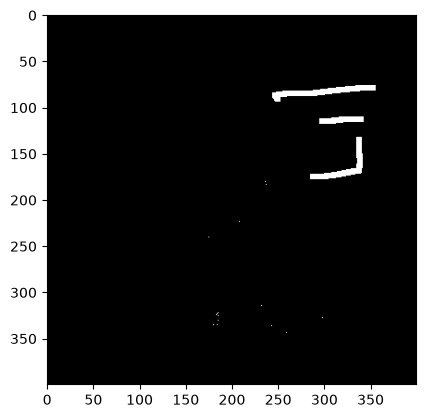

In [16]:
mask = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
plt.imshow(mask,cmap="gray")

Now if you use the above mask and apply the following inpainting algorithm then you would get same results. 

Inpainting Algorithms - OpenCV implements two inpainting algorithms:

"An Image Inpainting Technique Based on the Fast Marching Method", Alexandru Telea, 2004: This is based on Fast Marching Method (FMM). Looking at the region to be inpainted, the algorithm first starts with the boundary pixels and then goes to the pixels inside the boundary. It replaces each pixel to be inpainted with a weighted sum of the pixels in the background, with more weight given to nearer pixels and boundary pixels.

"Navier-Stokes, Fluid Dynamics, and Image and Video Inpainting", Bertalmio, Marcelo, Andrea L. Bertozzi, and Guillermo Sapiro, 2001: This algorithm is inspired by partial differential equations. Starting from the edges (known regions) towards the unknown regions, it propagates isophote lines (lines that join same-intensity points). Finally, variance in an area is minimized to fill colors.

FMM can be invoked by using cv2.INPAINT_TELEA, while Navier-Stokes can be invoked using cv2.INPAINT_NS. The Python code below inpaints the image of the cat using Navier-Stokes. 

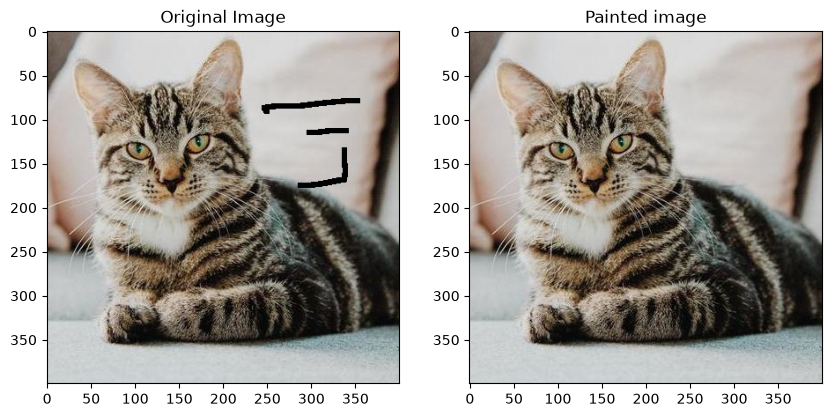

In [18]:
image = cv2.imread(r"C:\Users\Hp\Pictures\OpenCVSamples\cat_damaged.png")
image = cv2.cvtColor(image , cv2.COLOR_BGR2RGB)
dst = cv2.inpaint(image,mask,3,cv2.INPAINT_NS)

plt.figure(figsize=(10,10))
plt.subplot(121)
plt.imshow(image)
plt.title("Original Image")
plt.subplot(122)
plt.imshow(dst)
plt.title("Painted image")

plt.show()

How does image registration work? 

Alignment can be looked at as a simple coordinate transform. The algorithm works as follows:  

Convert both images to grayscale.

Match features from the image to be aligned, to the reference image and store the coordinates of the corresponding key points. 

Keypoints are simply the selected few points that are used to compute the transform (generally points that stand out), and descriptors are histograms of the image gradients to characterize the appearance of a keypoint. 

In this post, we use ORB (Oriented FAST and Rotated BRIEF) implementation in the OpenCV library, which provides us with both key points as well as their associated descriptors.
Match the key points between the two images. 

In this post, we use BFMatcher, which is a brute force matcher. BFMatcher.match() retrieves the best match, while BFMatcher.knnMatch() retrieves top K matches, where K is specified by the user.

Pick the top matches, and remove the noisy matches.

Find the homomorphy transform.

Apply this transform to the original unaligned image to get the output image.

Image registration = make two images line up.

In [ ]:
# import cv2
# import numpy as np

# # Open the image files.
# img1_color = cv2.imread("align.jpg")  # Image to be aligned.
# img2_color = cv2.imread("ref.jpg")    # Reference image.

# # Convert to grayscale.
# img1 = cv2.cvtColor(img1_color, cv2.COLOR_BGR2GRAY)
# img2 = cv2.cvtColor(img2_color, cv2.COLOR_BGR2GRAY)
# height, width = img2.shape

# # Create ORB detector with 5000 features.
# orb_detector = cv2.ORB_create(5000)

# # Find keypoints and descriptors.
# # The first arg is the image, second arg is the mask
# #  (which is not required in this case).
# kp1, d1 = orb_detector.detectAndCompute(img1, None)
# kp2, d2 = orb_detector.detectAndCompute(img2, None)

# # Match features between the two images.
# # We create a Brute Force matcher with 
# # Hamming distance as measurement mode.
# matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck = True)

# # Match the two sets of descriptors.
# matches = matcher.match(d1, d2)

# # Sort matches on the basis of their Hamming distance.
# matches.sort(key = lambda x: x.distance)

# # Take the top 90 % matches forward.
# matches = matches[:int(len(matches)*0.9)]
# no_of_matches = len(matches)

# # Define empty matrices of shape no_of_matches * 2.
# p1 = np.zeros((no_of_matches, 2))
# p2 = np.zeros((no_of_matches, 2))

# for i in range(len(matches)):
#   p1[i, :] = kp1[matches[i].queryIdx].pt
#   p2[i, :] = kp2[matches[i].trainIdx].pt

# # Find the homography matrix.
# homography, mask = cv2.findHomography(p1, p2, cv2.RANSAC)

# # Use this matrix to transform the
# # colored image wrt the reference image.
# transformed_img = cv2.warpPerspective(img1_color,
#                     homography, (width, height))

# # Save the output.
# cv2.imwrite('output.jpg', transformed_img)